
# Time Series Analysis in Python III
## Non-Stationary Time Series and Heteroskedasticity

**Reference**: https://www.sta.cuhk.edu.hk/nhchan/TSBook2nd/book2.html

<a target="_blank" href="https://colab.research.google.com/github/cspun/TSA/blob/main/tsa-III.ipynb">
<img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

This notebook extends the earlier notebooks and follows the same **analysis workflow**:

1. **Plot the raw series** and look for trend, seasonality, changing variance, and outliers.  
2. **Transform / difference if needed** to stabilize mean and variance.  
3. **Use ADF and KPSS tests** as formal support for the stationarity decision.  
4. **Fit a mean model** (ARIMA / ARMA) and check residual diagnostics.  
5. **Test for heteroskedasticity** using squared residuals and the ARCH-LM test.  
6. **Fit ARCH / GARCH models** when volatility clustering remains.  
7. **Forecast** the mean and, when appropriate, the conditional variance.

We use two real datasets:

- **`ustbill.dat`**: monthly U.S. 3-month Treasury bill rates, connecting directly to the earlier ARIMA forecasting notebook.
- **`exchange.dat`**: weekly USD/GBP exchange rates, following the foreign exchange example in the heteroskedasticity chapter.

The notebook is designed to mirror the lecture logic:
- Lecture 6: transformation, differencing, ADF/KPSS, ARIMA diagnostics.
- Lecture 7: volatility clustering, heavy tails, ARCH-LM, GARCH(1,1).


## 0. Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy import stats
from scipy.optimize import minimize

from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import acf, pacf, adfuller, kpss
from statsmodels.stats.diagnostic import acorr_ljungbox, het_arch
from statsmodels.tsa.holtwinters import ExponentialSmoothing

np.set_printoptions(precision=4, suppress=True)
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["figure.dpi"] = 120

## Shared helper functions
These keep the notebook style consistent with the earlier `tsa-II.ipynb` notebook.

In [2]:

def to_2col_array(ci):
    """Return conf_int as a (h,2) numpy array, robust to DataFrame/ndarray."""
    return np.asarray(ci)

def plot_series(y, title, xlabel="t", ylabel="value"):
    plt.figure(figsize=(10,5))
    x_axis = y.index if hasattr(y, "index") else np.arange(1, len(y)+1)
    y_vals = y.values if hasattr(y, "values") else y
    plt.plot(x_axis, y_vals, linewidth=1)
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.tight_layout()
    plt.show()

def plot_acf_pacf(y, nlags=24, pacf_method="ywm"):
    yy = np.asarray(y)
    n = len(yy)
    nlags = min(nlags, n//2 - 1)
    nlags = max(nlags, 1)

    r = acf(yy, nlags=nlags, fft=False)
    p = pacf(yy, nlags=nlags, method=pacf_method)

    band = 1.96 / np.sqrt(n)

    plt.figure(figsize=(10,5))
    plt.stem(range(nlags+1), r, basefmt=" ")
    plt.axhline(0, linewidth=1)
    plt.axhline(band, linestyle="--", linewidth=1)
    plt.axhline(-band, linestyle="--", linewidth=1)
    plt.title(f"Sample ACF (nlags={nlags}), bands = ±1.96/√n (n={n})")
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(10,5))
    plt.stem(range(nlags+1), p, basefmt=" ")
    plt.axhline(0, linewidth=1)
    plt.axhline(band, linestyle="--", linewidth=1)
    plt.axhline(-band, linestyle="--", linewidth=1)
    plt.title(f"Sample PACF (nlags={nlags}), bands = ±1.96/√n (n={n})")
    plt.tight_layout()
    plt.show()

    return r, p

def residual_report(fit, lags=(8,12,16,20)):
    resid = np.asarray(fit.resid)
    lb = acorr_ljungbox(resid, lags=list(lags), return_df=True)
    return resid, lb

def plot_resid_acf(resid, nlags=24, title="Residual ACF"):
    rr = np.asarray(resid)
    n = len(rr)
    nlags = min(nlags, n - 1)

    r = acf(rr, nlags=nlags, fft=False)
    band = 1.96 / np.sqrt(n)

    plt.figure(figsize=(10,5))
    plt.stem(range(nlags+1), r, basefmt=" ")
    plt.axhline(0, linewidth=1)
    plt.axhline(band, linestyle="--", linewidth=1)
    plt.axhline(-band, linestyle="--", linewidth=1)
    plt.title(f"{title} (bands = ±1.96/√n, n={n})")
    plt.tight_layout()
    plt.show()

def forecast_table_and_plot(fit, steps, y, title_prefix="Forecast"):
    fc = fit.get_forecast(steps=steps)
    mean_fc = np.asarray(fc.predicted_mean)
    ci_arr = to_2col_array(fc.conf_int(alpha=0.05))

    n = len(y)
    idx = np.arange(n+1, n+steps+1)
    fc_df = pd.DataFrame({
        "forecast": mean_fc,
        "lower_95": ci_arr[:,0],
        "upper_95": ci_arr[:,1],
    }, index=idx)

    plt.figure(figsize=(10,5))
    plt.plot(np.arange(1, n+1), np.asarray(y), label="observed", linewidth=1)
    t_fc = np.arange(n+1, n+steps+1)
    plt.plot(t_fc, mean_fc, label="forecast", linewidth=2)
    plt.fill_between(t_fc, ci_arr[:,0], ci_arr[:,1], alpha=0.2, label="95% PI")
    plt.title(f"{title_prefix}")
    plt.xlabel("t")
    plt.tight_layout()
    plt.legend()
    plt.show()

    return fc_df

def ets_benchmarks(y, seasonal_periods=None, seasonal=None):
    yy = pd.Series(y).astype(float)
    ses = ExponentialSmoothing(yy, trend=None, seasonal=None).fit(optimized=True)
    holt = ExponentialSmoothing(yy, trend="add", seasonal=None, damped_trend=False).fit(optimized=True)
    hw = None
    if seasonal_periods is not None and seasonal is not None:
        hw = ExponentialSmoothing(yy, trend="add", seasonal=seasonal,
                                  seasonal_periods=seasonal_periods).fit(optimized=True)
    return ses, holt, hw

def plot_ets_forecasts(y, steps, ses, holt, hw=None, title="ETS benchmarks"):
    yy = np.asarray(y)
    n = len(yy)
    t = np.arange(1, n+1)
    t_fc = np.arange(n+1, n+steps+1)

    f_ses = ses.forecast(steps)
    f_holt = holt.forecast(steps)

    plt.figure(figsize=(10,5))
    plt.plot(t, yy, label="observed", linewidth=1)
    plt.plot(t_fc, f_ses, label="SES", linewidth=2)
    plt.plot(t_fc, f_holt, label="Holt", linewidth=2)
    if hw is not None:
        f_hw = hw.forecast(steps)
        plt.plot(t_fc, f_hw, label="Holt-Winters", linewidth=2)

    plt.title(title)
    plt.xlabel("t")
    plt.tight_layout()
    plt.legend()
    plt.show()

def forecast_df(fit, steps, n_obs):
    fc = fit.get_forecast(steps=steps)
    mean_fc = np.asarray(fc.predicted_mean)
    ci = np.asarray(fc.conf_int(alpha=0.05))
    idx = np.arange(n_obs+1, n_obs+steps+1)
    return pd.DataFrame({
        "forecast": mean_fc,
        "lower_95": ci[:,0],
        "upper_95": ci[:,1]
    }, index=idx)

def forecast_plot(y, fc_df, title="Forecast with 95% PI"):
    y = np.asarray(y)
    n = len(y)
    t = np.arange(1, n+1)
    t_fc = fc_df.index.values
    plt.figure(figsize=(10,5))
    plt.plot(t, y, label="observed", linewidth=1.5)
    plt.plot(t_fc, fc_df["forecast"].values, label="forecast", linewidth=2)
    plt.fill_between(t_fc, fc_df["lower_95"].values, fc_df["upper_95"].values, alpha=0.2, label="95% PI")
    plt.title(title)
    plt.xlabel("t")
    plt.tight_layout()
    plt.legend()
    plt.show()


## Extra utilities for unit root tests and heteroskedasticity

In [3]:

def unit_root_summary(y, name="series"):
    rows = []
    for reg, label in [("c", "constant"), ("ct", "constant + trend")]:
        try:
            adf_res = adfuller(y, regression=reg, autolag="AIC")
            rows.append({
                "series": name,
                "test": f"ADF ({label})",
                "stat": adf_res[0],
                "pvalue": adf_res[1],
                "usedlag": adf_res[2]
            })
        except Exception as e:
            rows.append({
                "series": name,
                "test": f"ADF ({label})",
                "stat": np.nan,
                "pvalue": np.nan,
                "usedlag": np.nan
            })
        try:
            kpss_res = kpss(y, regression=reg, nlags="auto")
            rows.append({
                "series": name,
                "test": f"KPSS ({label})",
                "stat": kpss_res[0],
                "pvalue": kpss_res[1],
                "usedlag": kpss_res[2]
            })
        except Exception:
            rows.append({
                "series": name,
                "test": f"KPSS ({label})",
                "stat": np.nan,
                "pvalue": np.nan,
                "usedlag": np.nan
            })
    return pd.DataFrame(rows)

def arch_lm_table(y, nlags=4):
    lm_stat, lm_pvalue, f_stat, f_pvalue = het_arch(y, nlags=nlags)
    return pd.DataFrame({
        "LM stat": [lm_stat],
        "LM p-value": [lm_pvalue],
        "F stat": [f_stat],
        "F p-value": [f_pvalue],
        "lags": [nlags]
    })

def plot_hist_density_qq(y, title_prefix="Series"):
    yy = np.asarray(y)
    mu, sig = yy.mean(), yy.std(ddof=0)
    x = np.linspace(mu - 4*sig, mu + 4*sig, 400)

    plt.figure(figsize=(10,5))
    plt.hist(yy, bins=30, density=True, alpha=0.5, label="Histogram")
    kde = stats.gaussian_kde(yy)
    plt.plot(x, kde(x), linewidth=2, label="Kernel density")
    plt.plot(x, stats.norm.pdf(x, loc=mu, scale=sig), linewidth=2, label="Normal density")
    plt.title(f"{title_prefix}: histogram, kernel density, and normal density")
    plt.tight_layout()
    plt.legend()
    plt.show()

    plt.figure(figsize=(10,5))
    stats.probplot(yy, dist="norm", plot=plt)
    plt.title(f"{title_prefix}: Normal Q-Q plot")
    plt.tight_layout()
    plt.show()

def get_param(fit, *candidates, default=np.nan):
    names = list(getattr(fit, "param_names", []))
    params = np.asarray(fit.params)
    for c in candidates:
        if c in names:
            return float(params[names.index(c)])
    return default

def fit_arch1(y):
    y = np.asarray(y, dtype=float)
    y = y - np.mean(y)
    n = len(y)
    var0 = np.var(y)
    def unpack(u):
        omega = np.exp(u[0])
        ea = np.exp(u[1])
        alpha = ea / (1 + ea)
        return omega, alpha
    def nll(u):
        omega, alpha = unpack(u)
        h = np.empty(n)
        h[0] = max(var0, omega / max(1e-6, 1-alpha))
        for t in range(1, n):
            h[t] = omega + alpha * y[t-1]**2
        return 0.5 * np.sum(np.log(h) + y**2 / h)
    res = minimize(nll, [np.log(var0*0.1), np.log(0.1/0.9)], method="L-BFGS-B")
    omega, alpha = unpack(res.x)
    h = np.empty(n)
    h[0] = max(var0, omega / max(1e-6, 1-alpha))
    for t in range(1, n):
        h[t] = omega + alpha * y[t-1]**2
    ll = -nll(res.x)
    return {
        "omega": omega, "alpha": alpha, "loglik": ll, "aic": 2*2 - 2*ll,
        "bic": np.log(n)*2 - 2*ll, "h": h, "resid": y/np.sqrt(h), "centered_y": y,
        "success": res.success
    }

def fit_garch11(y):
    y = np.asarray(y, dtype=float)
    y = y - np.mean(y)
    n = len(y)
    var0 = np.var(y)
    def unpack(u):
        omega = np.exp(u[0])
        ea, eb = np.exp(u[1]), np.exp(u[2])
        s = 1 + ea + eb
        alpha = ea / s
        beta = eb / s
        return omega, alpha, beta
    def nll(u):
        omega, alpha, beta = unpack(u)
        h = np.empty(n)
        h[0] = max(var0, omega / max(1e-6, 1-alpha-beta))
        for t in range(1, n):
            h[t] = omega + alpha * y[t-1]**2 + beta * h[t-1]
        return 0.5 * np.sum(np.log(h) + y**2 / h)
    starts = [
        [np.log(var0*0.01), np.log(0.07/0.03), np.log(0.90/0.03)],
        [np.log(var0*0.10), np.log(0.05/0.05), np.log(0.90/0.05)],
        [np.log(var0*0.01), np.log(0.10/0.10), np.log(0.80/0.10)],
    ]
    best = None
    for s in starts:
        r = minimize(nll, s, method="L-BFGS-B")
        if best is None or r.fun < best.fun:
            best = r
    omega, alpha, beta = unpack(best.x)
    h = np.empty(n)
    h[0] = max(var0, omega / max(1e-6, 1-alpha-beta))
    for t in range(1, n):
        h[t] = omega + alpha * y[t-1]**2 + beta * h[t-1]
    ll = -nll(best.x)
    return {
        "omega": omega, "alpha": alpha, "beta": beta, "loglik": ll, "aic": 2*3 - 2*ll,
        "bic": np.log(n)*3 - 2*ll, "h": h, "resid": y/np.sqrt(h), "centered_y": y,
        "success": best.success
    }

def garch_forecast_path(fit_dict, y, steps=10):
    y = np.asarray(y, dtype=float)
    y = y - np.mean(y)
    omega = fit_dict["omega"]
    alpha = fit_dict.get("alpha", 0.0)
    beta = fit_dict.get("beta", 0.0)
    h_last = fit_dict["h"][-1]
    y_last = y[-1]
    out = np.empty(steps)
    out[0] = omega + alpha * y_last**2 + beta * h_last
    for k in range(1, steps):
        out[k] = omega + (alpha + beta) * out[k-1]
    return out



# Example 1 — U.S. 3-month Treasury bill rates (`ustbill.dat`)

## Goal
This example connects directly to the previous notebook. The textbook Treasury bill analysis uses the monthly T-bill rates from 1950 to mid-1988, notes that the series is nonstationary in mean and variance, applies a **log transform** and then a **first difference**, and finally fits an **AR(6)** model to the differenced log series. The lecture notes also emphasize the workflow: **plot → transform/difference → ADF/KPSS → fit ARIMA/ARMA → check residuals**.


In [4]:

# The data file is arranged as a table by year-half, with the first column containing the date labels.
tb = pd.read_table("ustbill.dat", header=None, sep=r"\s+")
ttbill = tb.iloc[:, 1:].to_numpy().T.reshape(-1).astype(float)

n_tbill = len(ttbill)
print("Number of monthly observations:", n_tbill)
print("First 10 observations:", ttbill[:10])
print("Last 10 observations:", ttbill[-10:])


Number of monthly observations: 462
First 10 observations: [1.07 1.16 1.34 1.56 1.57 1.81 1.96 2.04 1.18 0.72]
Last 10 observations: [9.   9.87 8.06 6.95 7.1  6.21 5.53 5.67 5.77 6.46]



### Step 1: Plot the level series and the log-transformed series
We first inspect the original rates and their logarithms. A time series model should begin with simple plots before any formal testing.


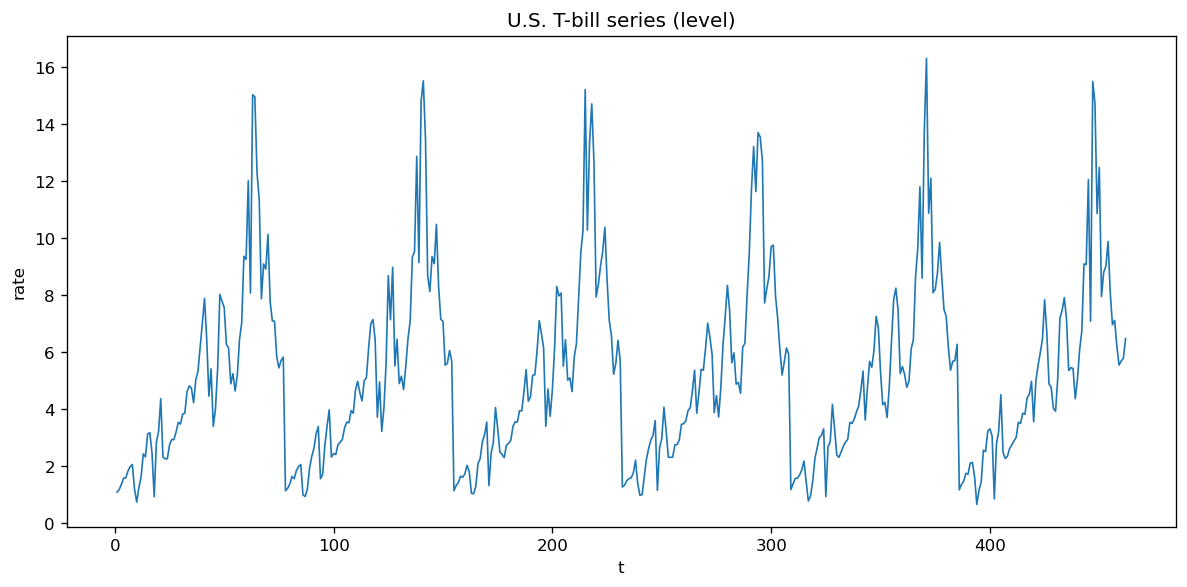

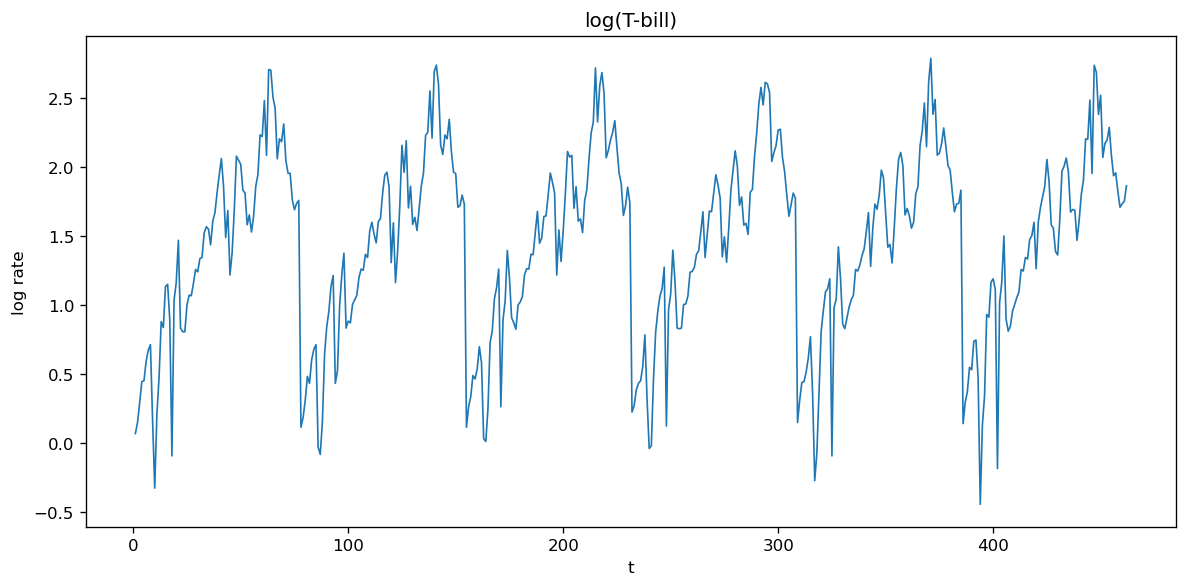

In [5]:

plot_series(ttbill, "U.S. T-bill series (level)", ylabel="rate")
plot_series(np.log(ttbill), "log(T-bill)", ylabel="log rate")



### Step 2: ACF/PACF and unit root tests
The textbook motivates working with **differenced logs**, because the level/log-level series show persistence and the transformed first differences behave more like a stationary return-like series. We use both **ADF** and **KPSS** as complementary tests:
- ADF: null = unit root / nonstationarity
- KPSS: null = stationarity


In [6]:

print("Unit root test summary: level series")
display(unit_root_summary(ttbill, name="ttbill"))

print("Unit root test summary: log series")
display(unit_root_summary(np.log(ttbill), name="log(ttbill)"))


Unit root test summary: level series


C:\Users\Cspun\AppData\Local\Temp\ipykernel_37748\1800738326.py:22: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_res = kpss(y, regression=reg, nlags="auto")
C:\Users\Cspun\AppData\Local\Temp\ipykernel_37748\1800738326.py:22: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_res = kpss(y, regression=reg, nlags="auto")


,series,test,stat,pvalue,usedlag
0,ttbill,ADF (constant),-4.164801,0.000755,18
1,ttbill,KPSS (constant),0.101954,0.100000,12
2,ttbill,ADF (constant + trend),-4.172564,0.004923,18
3,ttbill,KPSS (constant + trend),0.038608,0.100000,12


Unit root test summary: log series


C:\Users\Cspun\AppData\Local\Temp\ipykernel_37748\1800738326.py:22: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_res = kpss(y, regression=reg, nlags="auto")
C:\Users\Cspun\AppData\Local\Temp\ipykernel_37748\1800738326.py:22: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_res = kpss(y, regression=reg, nlags="auto")


,series,test,stat,pvalue,usedlag
0,log(ttbill),ADF (constant),-4.925374,0.000031,17
1,log(ttbill),KPSS (constant),0.124222,0.100000,12
2,log(ttbill),ADF (constant + trend),-4.921402,0.000285,17
3,log(ttbill),KPSS (constant + trend),0.042066,0.100000,12


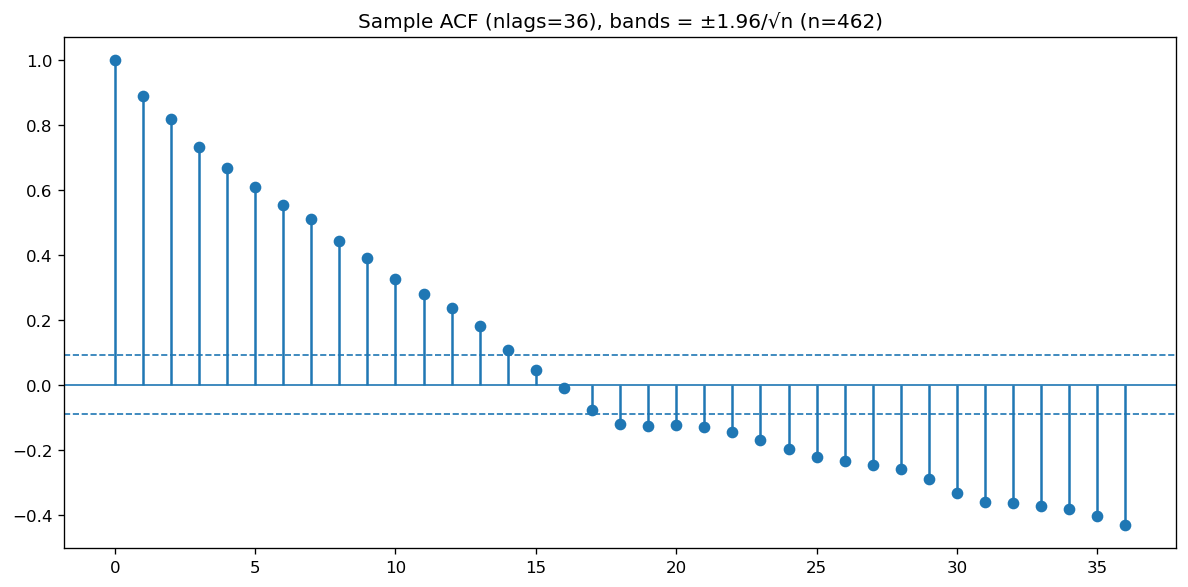

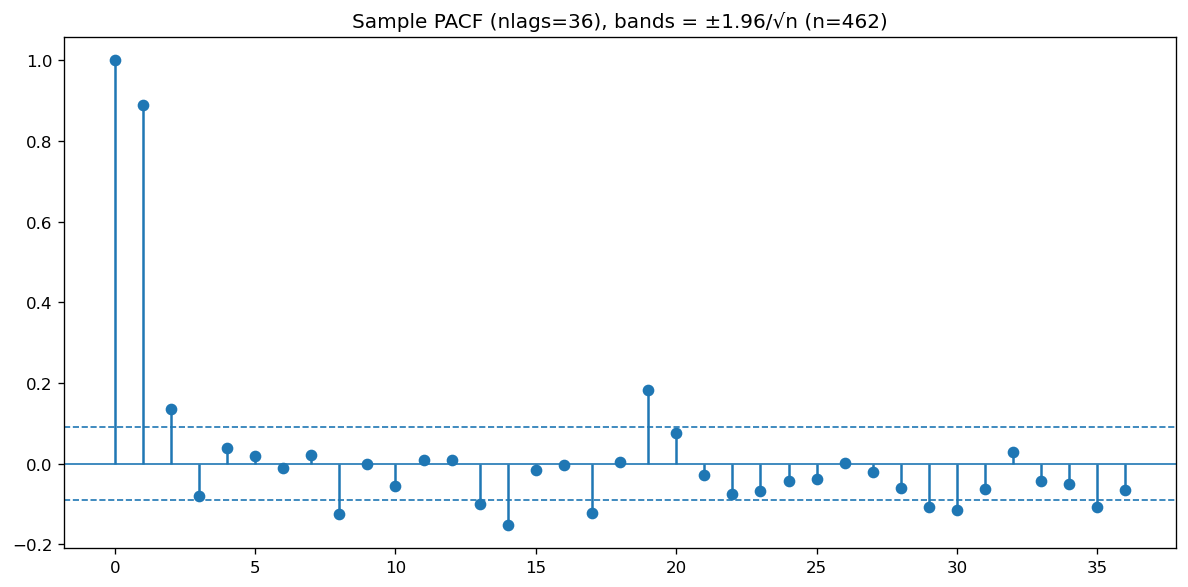

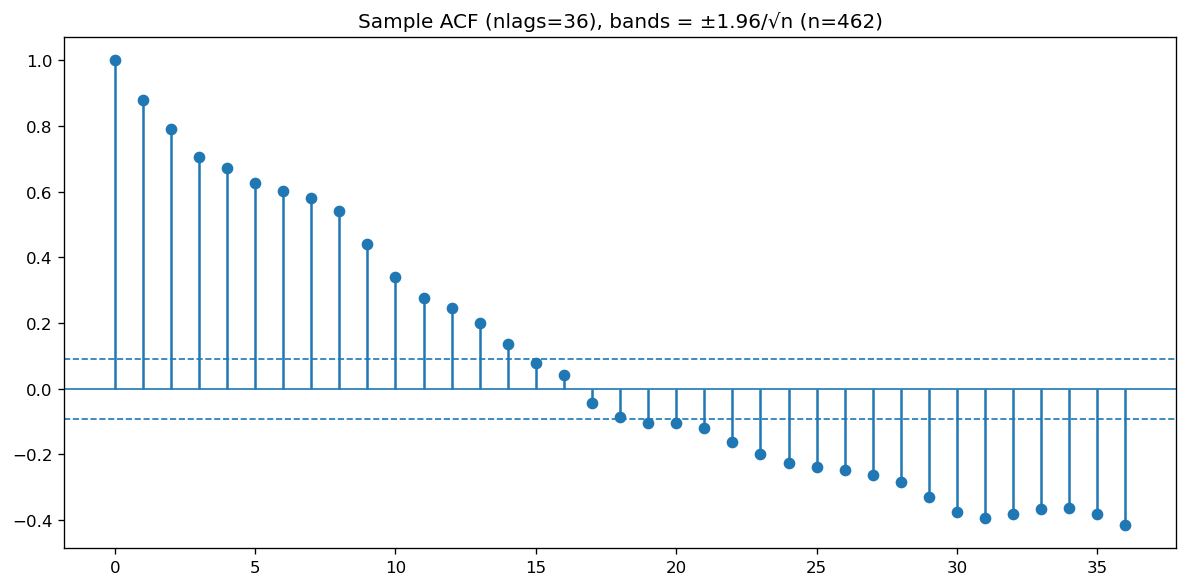

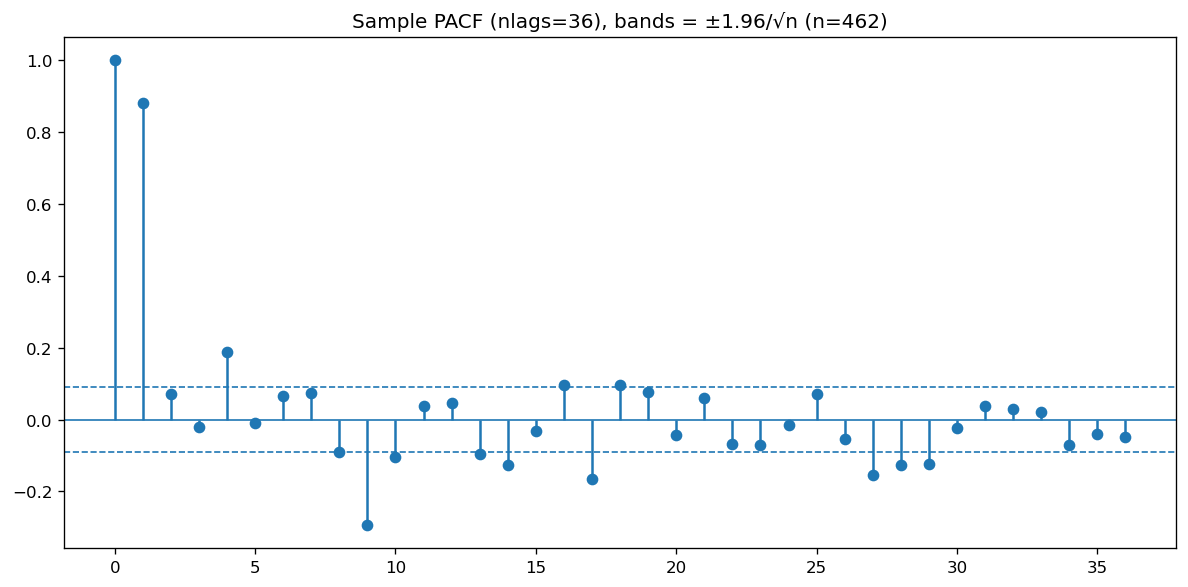

(array([ 1.    ,  0.8803,  0.7912,  0.705 ,  0.6711,  0.6276,  0.6021,
         0.5816,  0.5414,  0.4392,  0.341 ,  0.2762,  0.2467,  0.1985,
         0.1362,  0.0778,  0.04  , -0.0442, -0.0865, -0.1045, -0.1054,
        -0.1204, -0.162 , -0.2   , -0.2274, -0.2393, -0.2488, -0.264 ,
        -0.2852, -0.3294, -0.3751, -0.3944, -0.3812, -0.3652, -0.3624,
        -0.3805, -0.4157]),
 array([ 1.    ,  0.8803,  0.0719, -0.0211,  0.1879, -0.0111,  0.0645,
         0.0748, -0.0899, -0.2939, -0.1043,  0.0364,  0.0453, -0.0953,
        -0.1261, -0.033 ,  0.096 , -0.1655,  0.0974,  0.0758, -0.0422,
         0.0608, -0.0682, -0.0721, -0.0141,  0.0705, -0.0537, -0.1531,
        -0.1271, -0.1242, -0.0237,  0.0385,  0.0279,  0.0223, -0.0714,
        -0.0417, -0.0496]))

In [7]:

plot_acf_pacf(ttbill, nlags=36)
plot_acf_pacf(np.log(ttbill), nlags=36)



### Step 3: Difference the log series
Define $W_t = \Delta \log(X_t)$. This is approximately a monthly relative change. We now examine whether this transformed series behaves more like a stationary series.


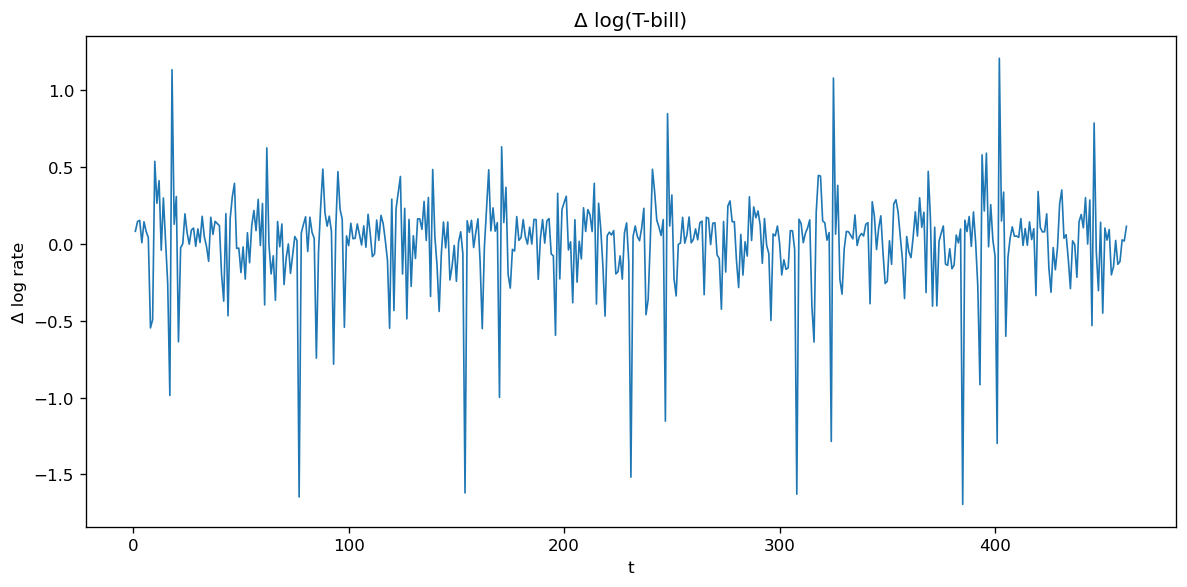

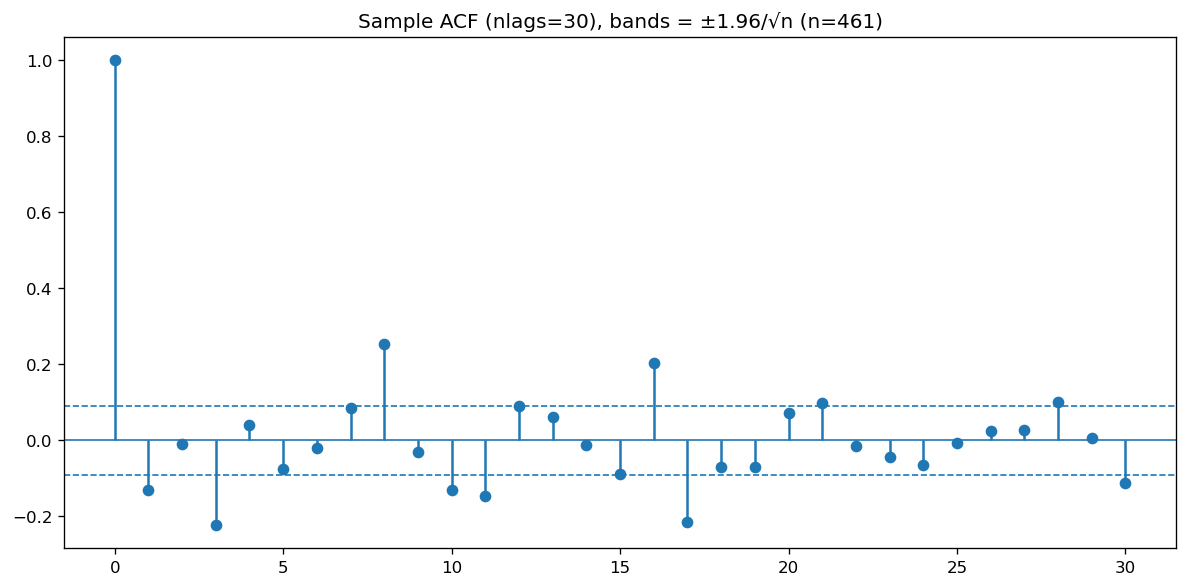

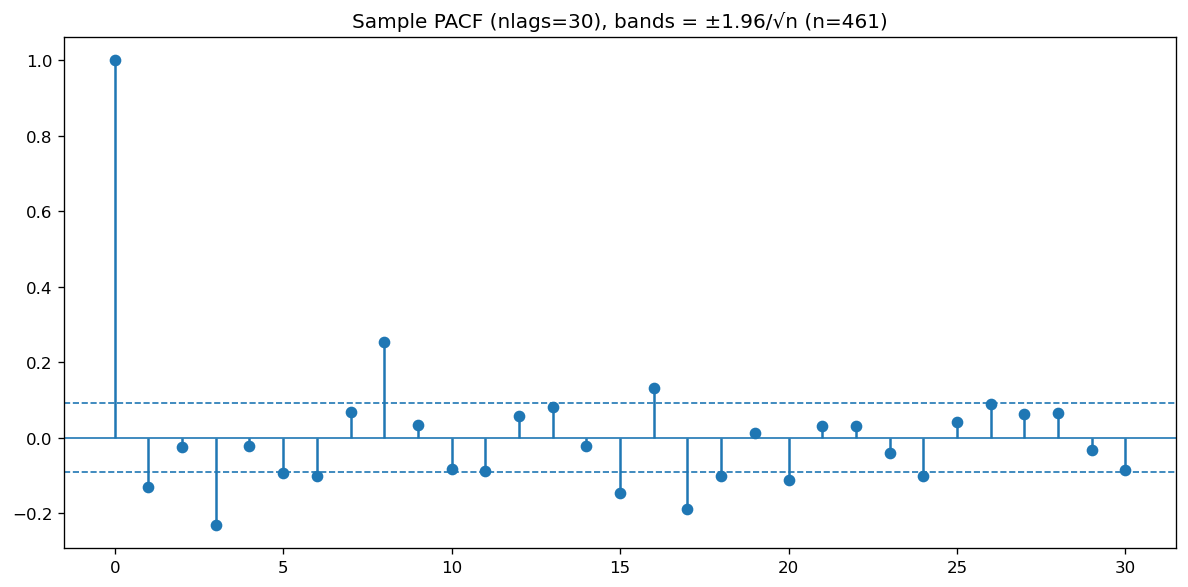

Unit root test summary: Δ log(T-bill)


C:\Users\Cspun\AppData\Local\Temp\ipykernel_37748\1800738326.py:22: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_res = kpss(y, regression=reg, nlags="auto")
C:\Users\Cspun\AppData\Local\Temp\ipykernel_37748\1800738326.py:22: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_res = kpss(y, regression=reg, nlags="auto")


,series,test,stat,pvalue,usedlag
0,dlntbill,ADF (constant),-6.294384,3.535137e-08,17
1,dlntbill,KPSS (constant),0.045709,1.000000e-01,28
2,dlntbill,ADF (constant + trend),-6.286596,5.382318e-07,17
3,dlntbill,KPSS (constant + trend),0.035662,1.000000e-01,29


In [8]:

dlntbill = np.diff(np.log(ttbill))
plot_series(dlntbill, "Δ log(T-bill)", ylabel="Δ log rate")
plot_acf_pacf(dlntbill, nlags=30)

print("Unit root test summary: Δ log(T-bill)")
display(unit_root_summary(dlntbill, name="dlntbill"))



### Interpretation so far
At this point, the workflow is:
- the raw series is persistent;
- the differenced log series is much more stable in level and variance;
- ACF/PACF of the differenced log series suggest a short-memory ARMA model rather than a unit-root model.



### Step 4: Candidate mean models for the transformed series
Following the textbook example, we compare:
- AR(6)
- MA(6)
- ARMA(6,6)

We center the transformed series before fitting models with `trend='n'`.


In [9]:

x = dlntbill - np.mean(dlntbill)

fit_ar6   = ARIMA(x, order=(6,0,0), trend="n").fit()
fit_ma6   = ARIMA(x, order=(0,0,6), trend="n").fit()
fit_arma  = ARIMA(x, order=(6,0,6), trend="n").fit()

cmp = pd.DataFrame({
    "model": ["AR(6)", "MA(6)", "ARMA(6,6)"],
    "AIC": [fit_ar6.aic, fit_ma6.aic, fit_arma.aic],
    "BIC": [fit_ar6.bic, fit_ma6.bic, fit_arma.bic]
}).sort_values("AIC")
cmp


C:\Users\Cspun\anaconda3\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
C:\Users\Cspun\anaconda3\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
C:\Users\Cspun\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


,model,AIC,BIC
2,"ARMA(6,6)",195.534870,249.269045
0,AR(6),232.724417,261.658203
1,MA(6),236.917887,265.851673



### Step 5: Residual diagnostics for the selected mean model
The lecture notes emphasize that **AIC/BIC must always be paired with diagnostics**. Even a model with a good AIC is not acceptable if the residuals are clearly non-white.


Selected mean model by AIC: ARMA(6,6)
                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                  461
Model:                 ARIMA(6, 0, 6)   Log Likelihood                 -84.767
Date:                Mon, 23 Mar 2026   AIC                            195.535
Time:                        08:34:54   BIC                            249.269
Sample:                             0   HQIC                           216.692
                                - 461                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.1476      0.430     -0.343      0.731      -0.990       0.695
ar.L2         -0.6215      0.202     -3.071      0.002      -1.018      -0.225
ar.L3         

,lb_stat,lb_pvalue
6,0.533893,0.997401
12,3.180176,0.994133
18,38.079358,0.003781
24,48.562252,0.002149


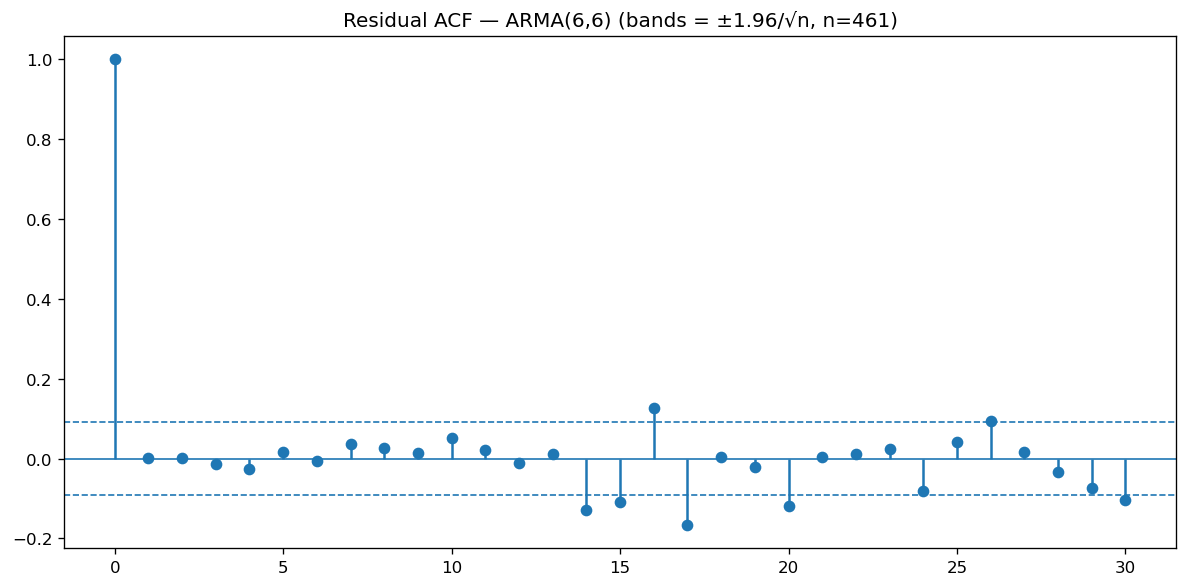

In [10]:

best_name = cmp.iloc[0]["model"]
fit_map = {"AR(6)": fit_ar6, "MA(6)": fit_ma6, "ARMA(6,6)": fit_arma}
best_fit = fit_map[best_name]

print("Selected mean model by AIC:", best_name)
print(best_fit.summary())

resid_tbill, lb_tbill = residual_report(best_fit, lags=(6,12,18,24))
display(lb_tbill)
plot_resid_acf(resid_tbill, nlags=30, title=f"Residual ACF — {best_name}")



### Step 6: Forecasting the transformed mean model
We perform a simple holdout exercise on the last 6 months, mirroring the earlier notebook and the textbook forecasting discussion.


In [11]:

h = 6
x_train = x[:-h]
fit_train = ARIMA(x_train, order=(6,0,0), trend="n").fit()

fc = fit_train.get_forecast(steps=h)
pred_x = np.asarray(fc.predicted_mean)

# Convert predicted Δlog back to level forecasts
pred_dlog = pred_x + np.mean(dlntbill)
mult = np.exp(pred_dlog)

start_level = ttbill[-(h+1)]
tfore = np.zeros(h)
tfore[0] = start_level * mult[0]
for i in range(1, h):
    tfore[i] = tfore[i-1] * mult[i]

fc_tbl = pd.DataFrame({
    "Actual": ttbill[-h:],
    "Forecast": tfore
}, index=np.arange(len(ttbill)-h+1, len(ttbill)+1))
fc_tbl


,Actual,Forecast
457,7.10,7.354759
458,6.21,7.712321
459,5.53,7.953445
460,5.67,7.973004
461,5.77,8.177517
462,6.46,8.186983


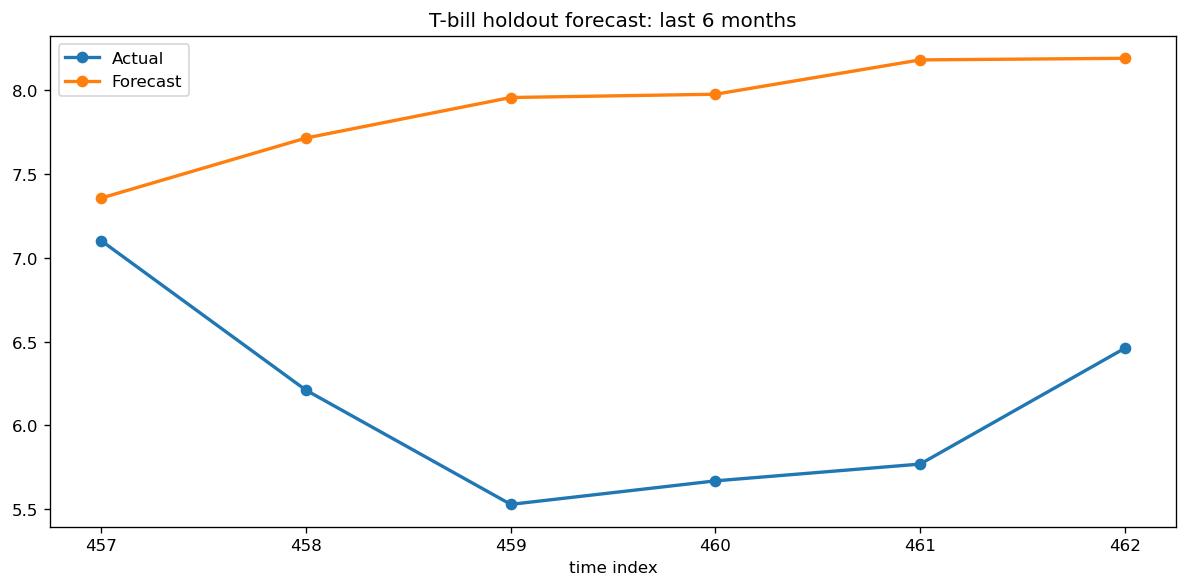

In [12]:

plt.figure(figsize=(10,5))
plt.plot(fc_tbl.index, fc_tbl["Actual"].values, marker="o", linewidth=2, label="Actual")
plt.plot(fc_tbl.index, fc_tbl["Forecast"].values, marker="o", linewidth=2, label="Forecast")
plt.title("T-bill holdout forecast: last 6 months")
plt.xlabel("time index")
plt.tight_layout()
plt.legend()
plt.show()



### Step 7: Check for remaining heteroskedasticity
For this transformed T-bill series, we can also test whether the residual variance is still predictable. If the ARCH-LM test is not significant, then a pure mean model may already be adequate; if significant, we would consider ARCH/GARCH.


ARCH-LM test on AR(6) residuals


,LM stat,LM p-value,F stat,F p-value,lags
0,4.612485,0.594384,0.764672,0.598025,6


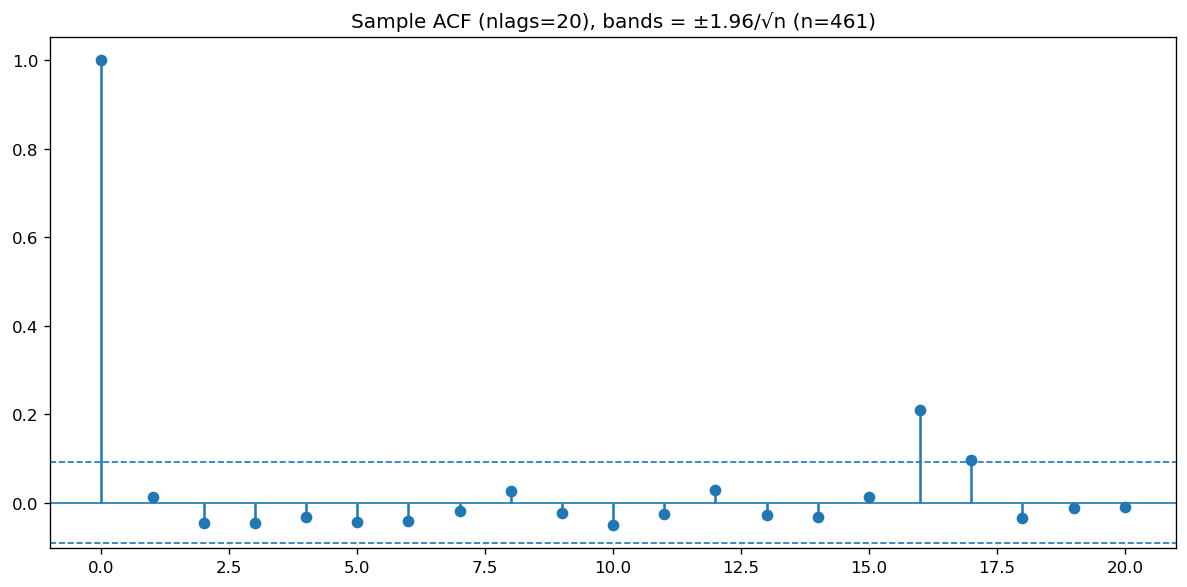

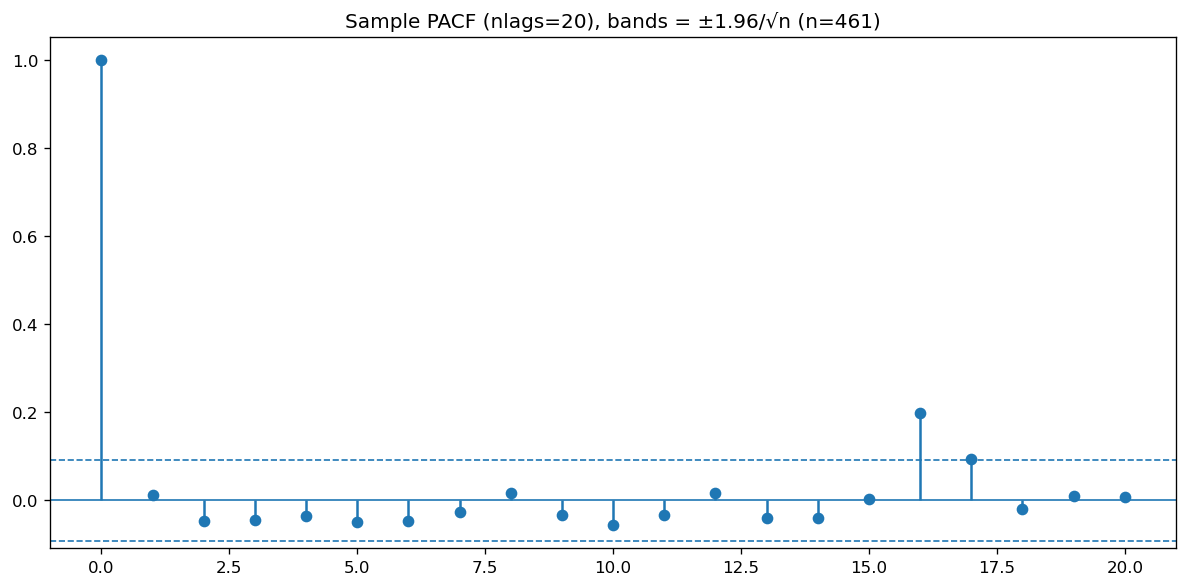

(array([ 1.    ,  0.0133, -0.0461, -0.0465, -0.0333, -0.0442, -0.0417,
        -0.0188,  0.026 , -0.0225, -0.0505, -0.0264,  0.0279, -0.0281,
        -0.0332,  0.0138,  0.2102,  0.0969, -0.035 , -0.0124, -0.0092]),
 array([ 1.    ,  0.0133, -0.0463, -0.0454, -0.0344, -0.0479, -0.0465,
        -0.0259,  0.0166, -0.0328, -0.0561, -0.0327,  0.0177, -0.0395,
        -0.0397,  0.004 ,  0.1991,  0.0939, -0.019 ,  0.0103,  0.007 ]))

In [13]:

print("ARCH-LM test on AR(6) residuals")
display(arch_lm_table(resid_tbill, nlags=6))
plot_acf_pacf(resid_tbill**2, nlags=20)



### Interpretation of Example 1
This example illustrates the full nonstationary workflow:
- begin in levels,
- stabilize by log transformation and differencing,
- use ADF/KPSS as formal support,
- fit a short-memory model to the transformed series,
- check residuals,
- then decide whether a volatility model is needed.

This is exactly the logic of Box–Jenkins, extended to nonstationary data.



# Example 2 — Weekly USD/GBP exchange rates (`exchange.dat`)

## Goal
This follows the foreign exchange example in the heteroskedasticity chapter. The textbook and lecture slides use the **first differences** of the exchange rate series, show that the differenced series is heavy-tailed, show dependence in squared differences, confirm heteroskedasticity by an **LM test**, and then fit a **GARCH(1,1)** model.


In [14]:

ex = np.loadtxt("exchange.dat", dtype=float).flatten()
dex = np.diff(ex)

print("Number of weekly observations:", len(ex))
print("Number of differenced observations:", len(dex))


Number of weekly observations: 470
Number of differenced observations: 469



### Step 1: Raw series and first difference
The level series is expected to be persistent / nonstationary, while the differenced series should behave more like a stationary return-like sequence.


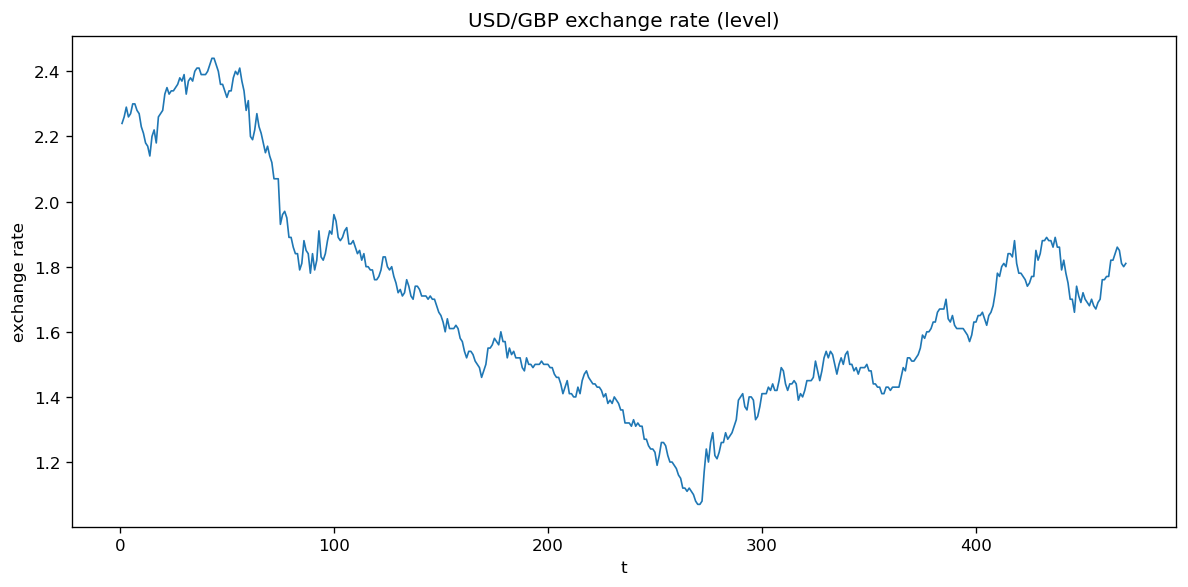

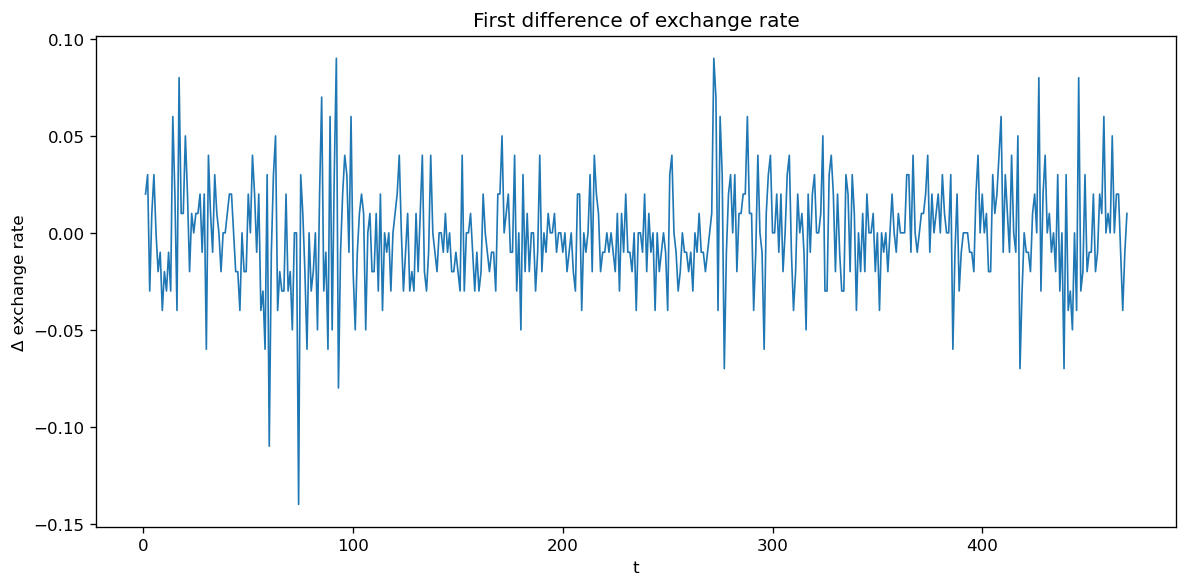

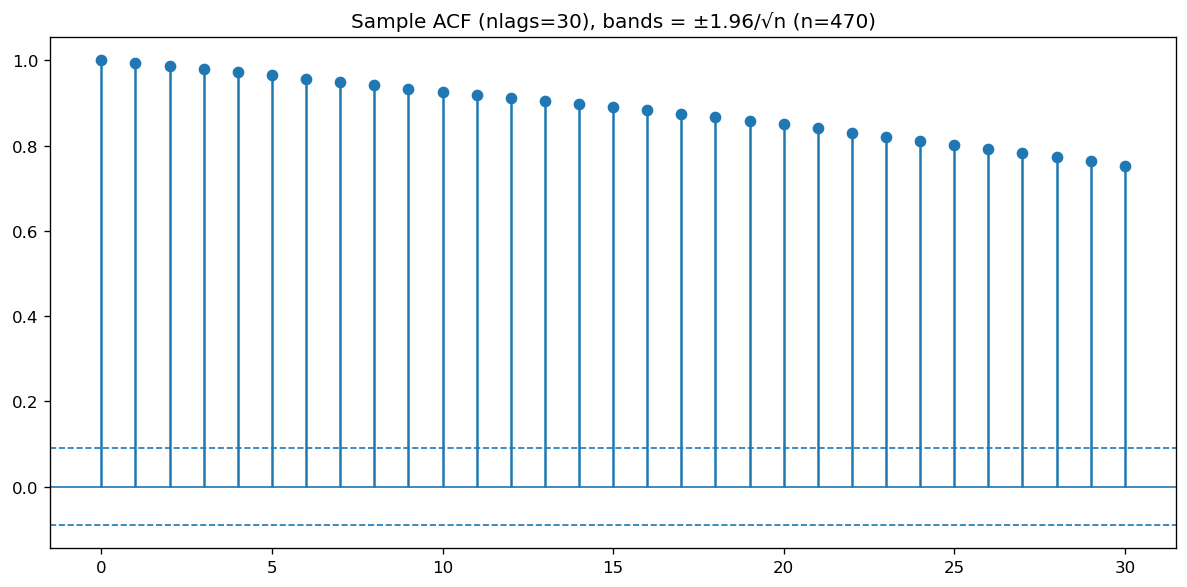

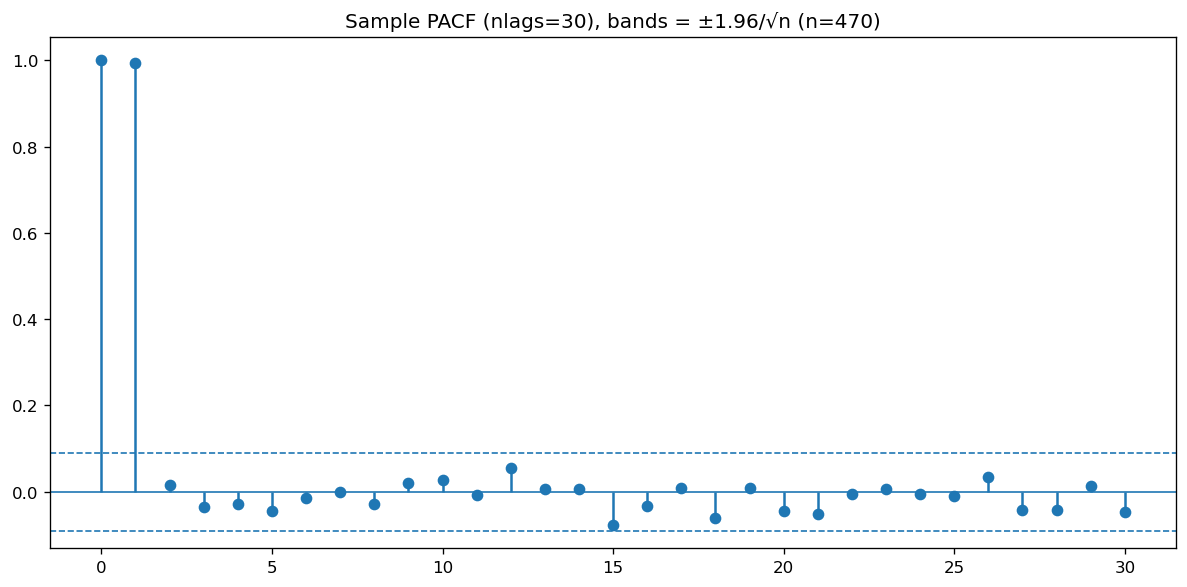

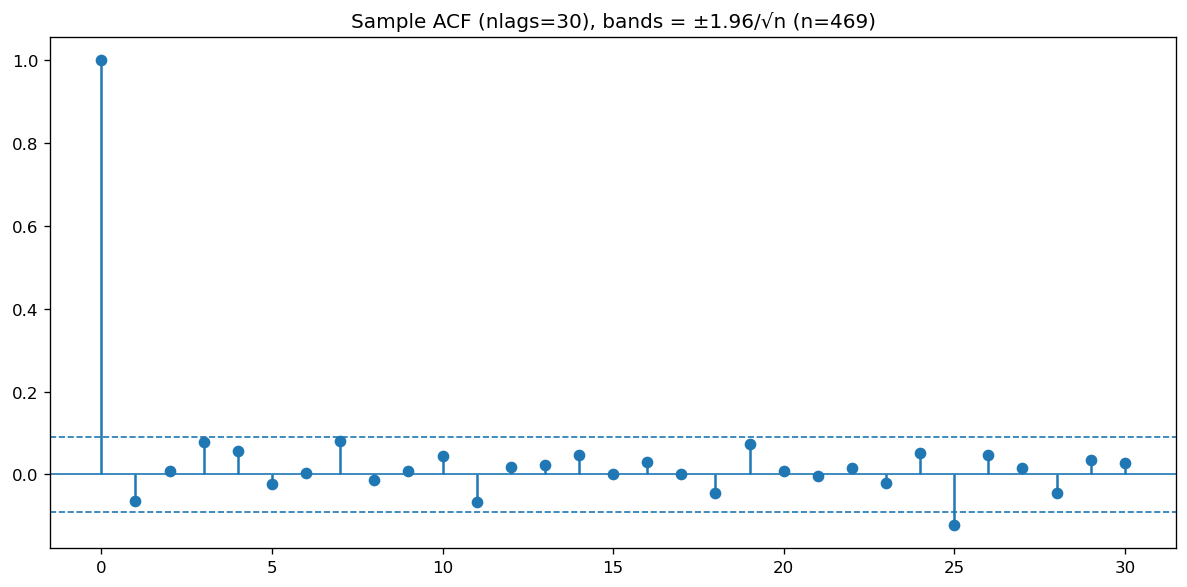

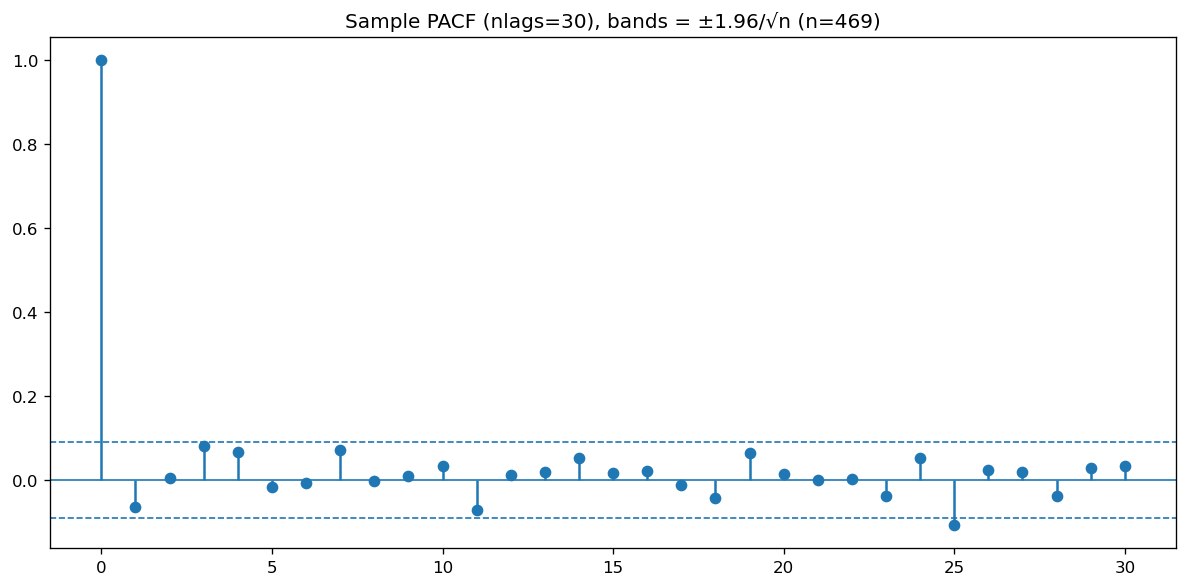

(array([ 1.    , -0.0642,  0.0086,  0.0791,  0.0566, -0.0228,  0.0035,
         0.0806, -0.0126,  0.0086,  0.0438, -0.0669,  0.0179,  0.0216,
         0.0475,  0.0017,  0.0288,  0.0004, -0.0448,  0.0735,  0.0074,
        -0.0051,  0.0147, -0.0221,  0.0516, -0.1226,  0.0455,  0.0146,
        -0.0446,  0.0342,  0.0275]),
 array([ 1.    , -0.0642,  0.0045,  0.0802,  0.0674, -0.0163, -0.007 ,
         0.0718, -0.0027,  0.0084,  0.0332, -0.0712,  0.0106,  0.0186,
         0.0519,  0.0164,  0.0202, -0.012 , -0.0432,  0.0637,  0.0138,
         0.0001,  0.0012, -0.0379,  0.0515, -0.1078,  0.0231,  0.0191,
        -0.0377,  0.0289,  0.0331]))

In [15]:

plot_series(ex, "USD/GBP exchange rate (level)", ylabel="exchange rate")
plot_series(dex, "First difference of exchange rate", ylabel="Δ exchange rate")
plot_acf_pacf(ex, nlags=30)
plot_acf_pacf(dex, nlags=30)



### Step 2: ADF and KPSS on level and differenced series
We use ADF and KPSS again to separate the nonstationary level series from the transformed series used for modeling.


In [16]:

print("Unit root test summary: exchange rate level")
display(unit_root_summary(ex, name="exchange"))

print("Unit root test summary: first difference")
display(unit_root_summary(dex, name="diff(exchange)"))


Unit root test summary: exchange rate level


C:\Users\Cspun\AppData\Local\Temp\ipykernel_37748\1800738326.py:22: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_res = kpss(y, regression=reg, nlags="auto")
C:\Users\Cspun\AppData\Local\Temp\ipykernel_37748\1800738326.py:22: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_res = kpss(y, regression=reg, nlags="auto")


,series,test,stat,pvalue,usedlag
0,exchange,ADF (constant),-1.659745,0.451963,0
1,exchange,KPSS (constant),1.694745,0.010000,12
2,exchange,ADF (constant + trend),-0.628122,0.977466,1
3,exchange,KPSS (constant + trend),0.860359,0.010000,12


Unit root test summary: first difference


C:\Users\Cspun\AppData\Local\Temp\ipykernel_37748\1800738326.py:22: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_res = kpss(y, regression=reg, nlags="auto")


,series,test,stat,pvalue,usedlag
0,diff(exchange),ADF (constant),-23.030425,0.000000,0
1,diff(exchange),KPSS (constant),0.559999,0.028153,4
2,diff(exchange),ADF (constant + trend),-23.230907,0.000000,0
3,diff(exchange),KPSS (constant + trend),0.076471,0.100000,3



### Step 3: Heavy tails and volatility clustering
The lecture material stresses two key stylized facts of financial returns:
- heavy tails,
- serial dependence in squared returns even when raw returns look weakly correlated.

We therefore examine:
- histogram + normal density + Q-Q plot,
- the series of squared differences,
- the ACF of squared differences.


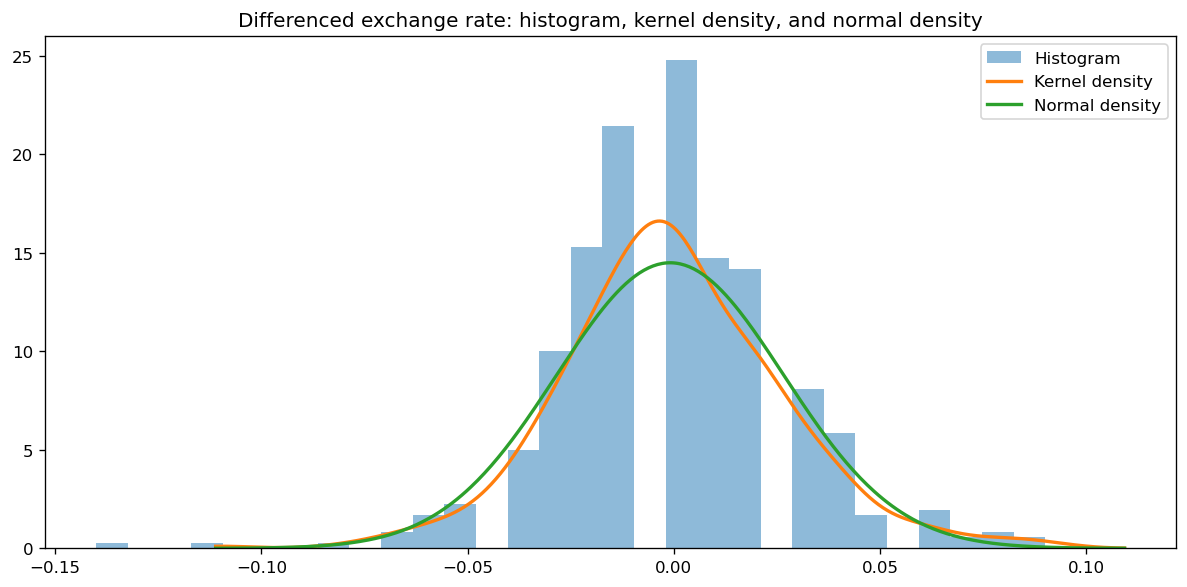

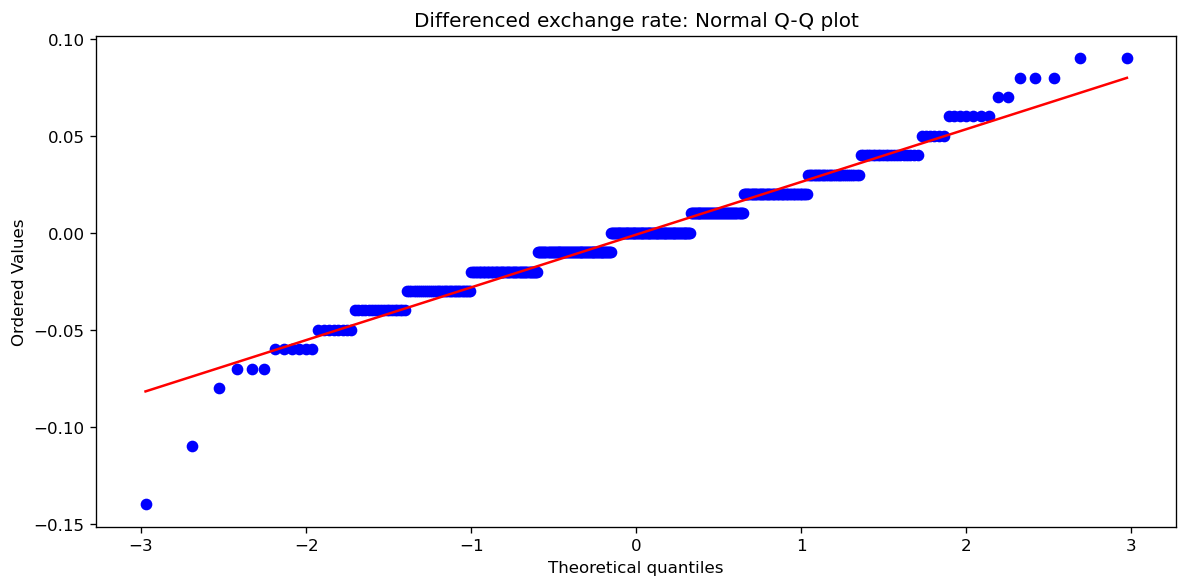

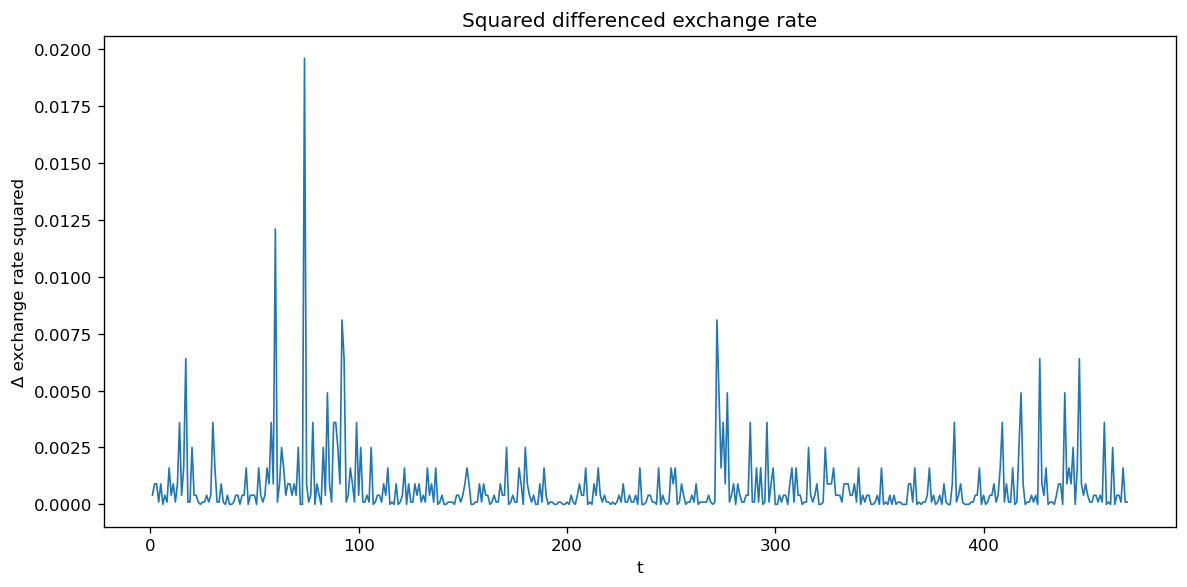

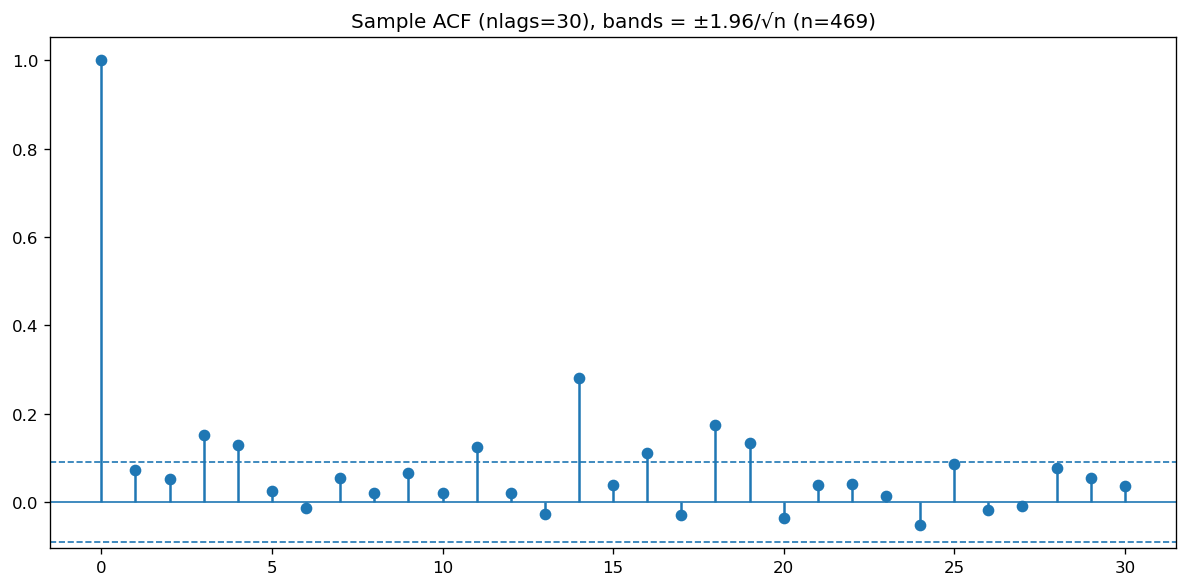

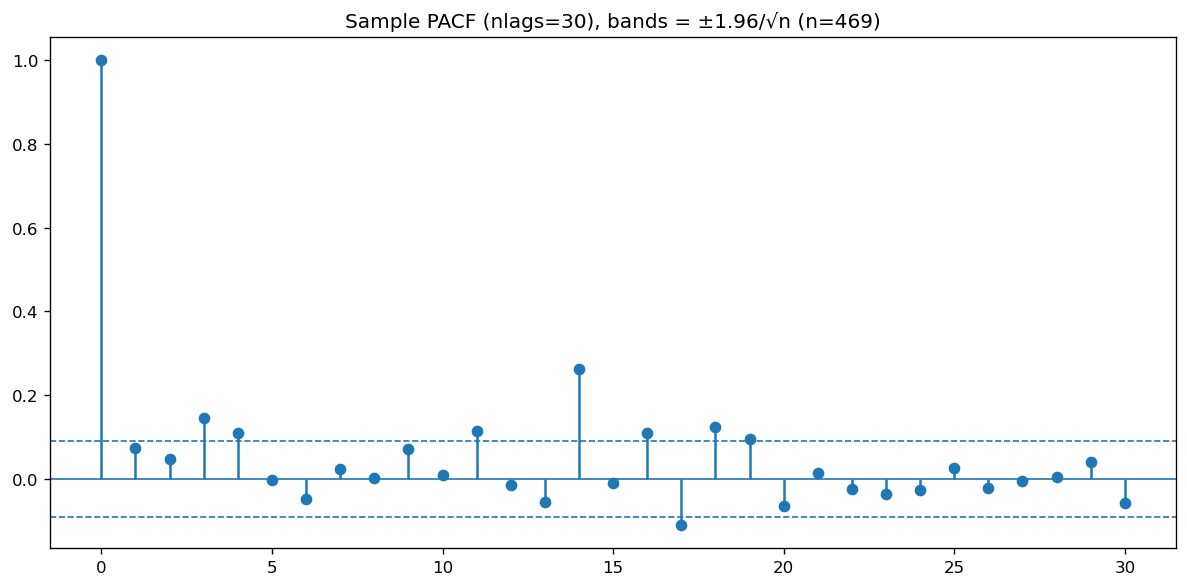

(array([ 1.    ,  0.0732,  0.0528,  0.1512,  0.1287,  0.0244, -0.0142,
         0.0546,  0.0212,  0.0657,  0.0192,  0.1255,  0.0211, -0.0271,
         0.2807,  0.0395,  0.1109, -0.0284,  0.1752,  0.1333, -0.0373,
         0.0378,  0.0418,  0.0128, -0.0524,  0.0867, -0.0189, -0.0082,
         0.0768,  0.0539,  0.0367]),
 array([ 1.    ,  0.0732,  0.0477,  0.1451,  0.1098, -0.0021, -0.0482,
         0.0233,  0.0029,  0.0712,  0.0089,  0.1132, -0.0152, -0.0555,
         0.2621, -0.0106,  0.1096, -0.1106,  0.123 ,  0.0948, -0.0645,
         0.013 , -0.0254, -0.0374, -0.0275,  0.0259, -0.0214, -0.0063,
         0.0038,  0.0405, -0.0568]))

In [17]:

plot_hist_density_qq(dex, title_prefix="Differenced exchange rate")
plot_series(dex**2, "Squared differenced exchange rate", ylabel="Δ exchange rate squared")
plot_acf_pacf(dex**2, nlags=30)



### Step 4: Heteroskedasticity test (ARCH-LM)
The textbook example regresses the squared differenced series on several lags of itself and obtains a small p-value, confirming heterogeneity. We reproduce that idea using the ARCH-LM test with 4 lags.


In [18]:

lm_tbl = arch_lm_table(dex, nlags=4)
lm_tbl


,LM stat,LM p-value,F stat,F p-value,lags
0,18.708321,0.000897,4.820742,0.000811,4



### Interpretation of the LM test
If the p-value is small, the null of no ARCH effect is rejected. Then the conditional variance depends on the past, so a GARCH-type model is appropriate.



### Step 5: Compare ARCH(1) and GARCH(1,1)
To keep the notebook self-contained, we fit Gaussian QMLE versions of:
- ARCH(1)
- GARCH(1,1)

The GARCH(1,1) fit should be close to the textbook result:
$$
\hat\sigma_t^2 \approx 3.1\times 10^{-5} + 0.067 X_{t-1}^2 + 0.89\,\hat\sigma_{t-1}^2.
$$


In [19]:

arch1 = fit_arch1(dex)
garch11 = fit_garch11(dex)

cmp_vol = pd.DataFrame({
    "model": ["ARCH(1)", "GARCH(1,1)"],
    "omega": [arch1["omega"], garch11["omega"]],
    "alpha": [arch1["alpha"], garch11["alpha"]],
    "beta": [np.nan, garch11["beta"]],
    "AIC": [arch1["aic"], garch11["aic"]],
    "BIC": [arch1["bic"], garch11["bic"]]
})
cmp_vol


,model,omega,alpha,beta,AIC,BIC
0,ARCH(1),0.000690,0.090589,NaN,-2901.150618,-2892.849412
1,"GARCH(1,1)",0.000031,0.066931,0.892507,-2926.741225,-2914.289417



### Step 6: Standardized residual diagnostics
For a well-fitted GARCH model:
- standardized residuals should have little serial correlation,
- squared standardized residuals should also have little serial correlation,
- the model should absorb the volatility clustering seen in the raw differenced series.


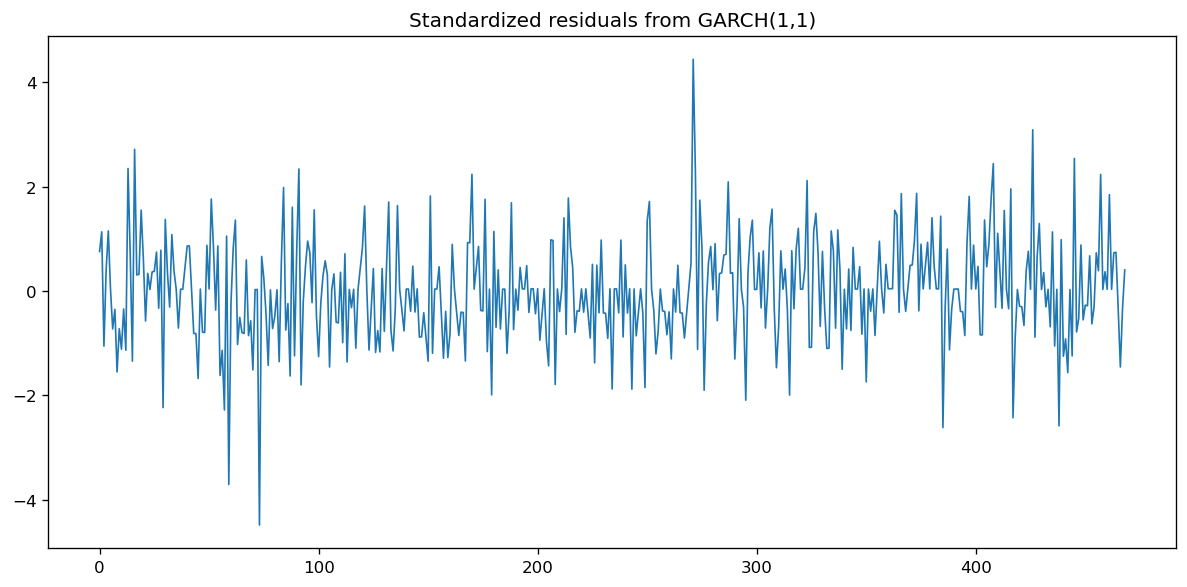

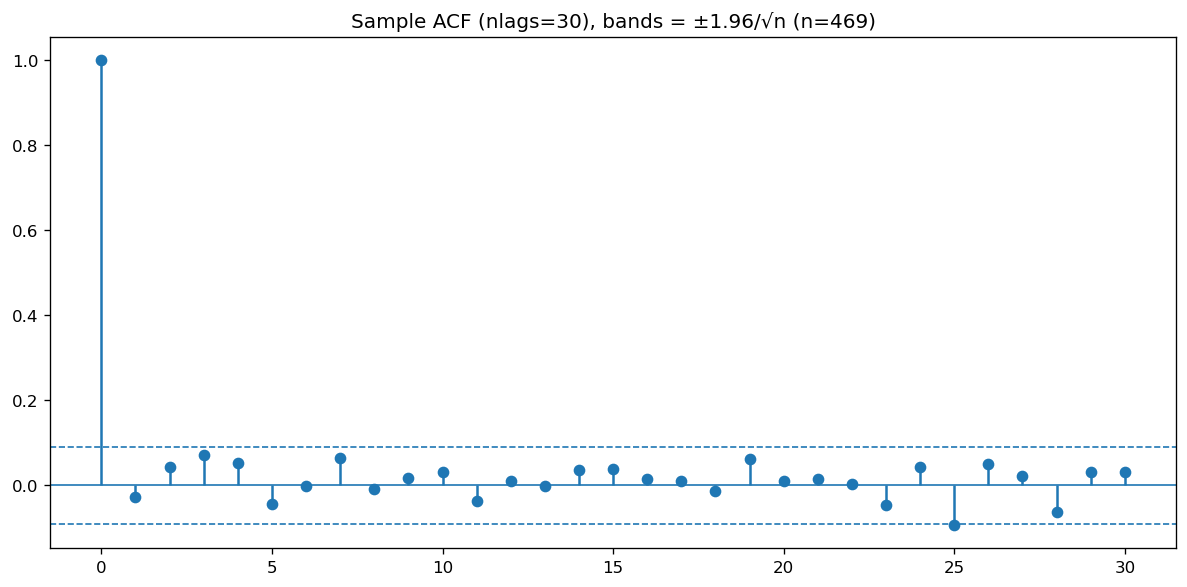

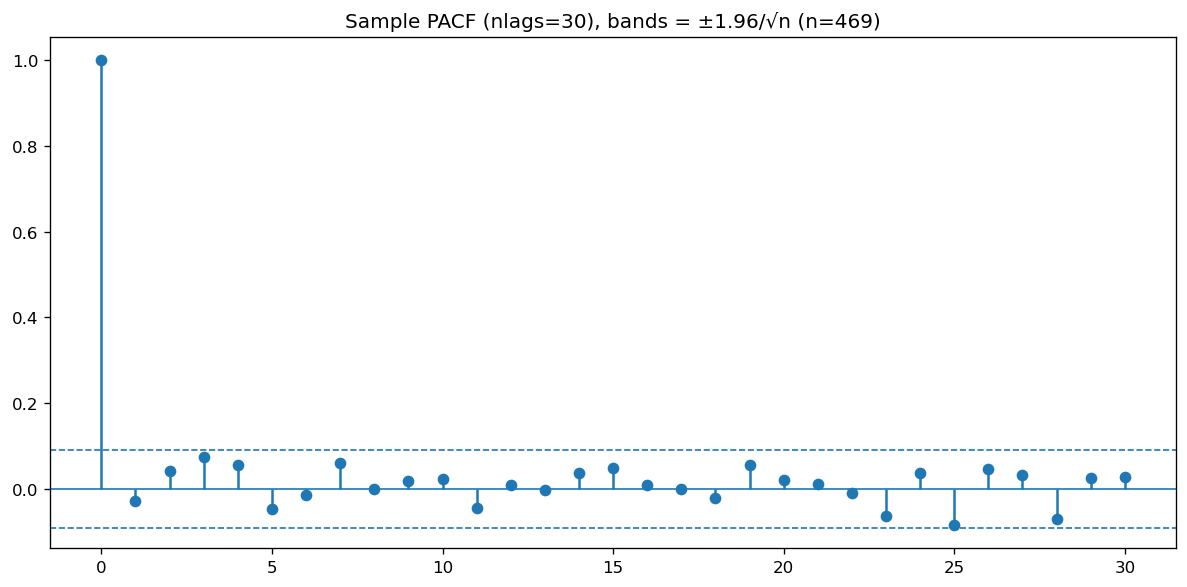

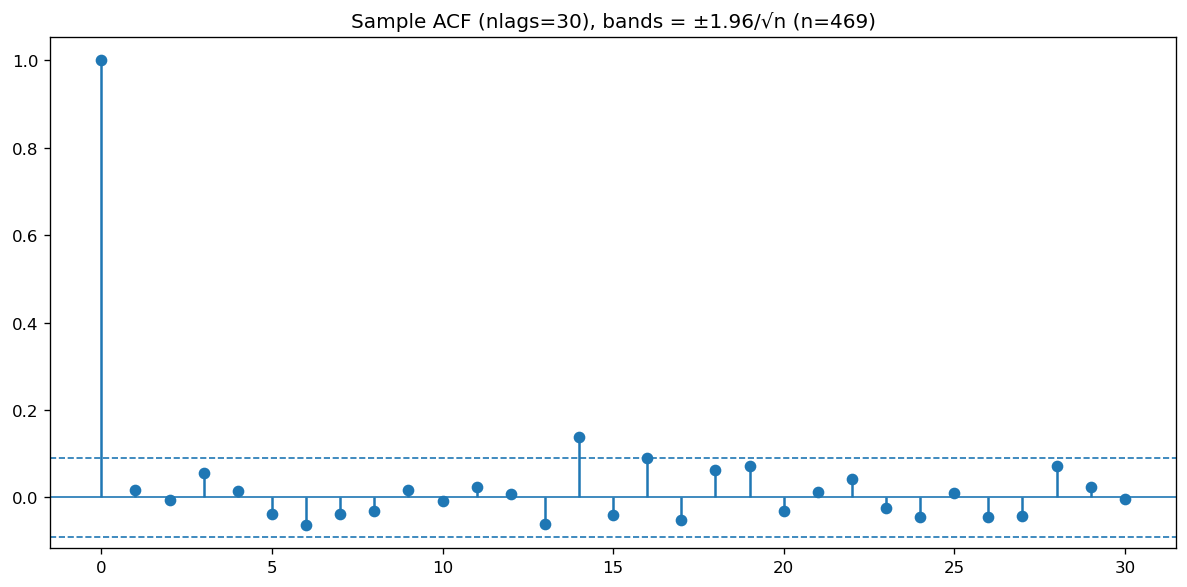

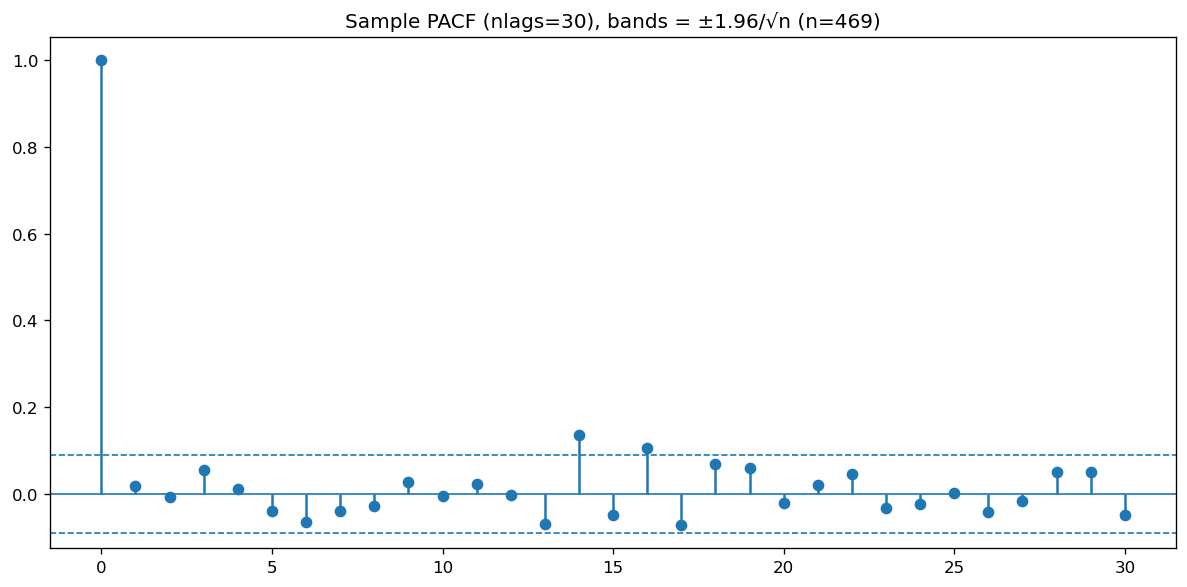

ARCH-LM test on squared standardized residuals


,LM stat,LM p-value,F stat,F p-value,lags
0,1.623462,0.804569,0.402908,0.806578,4


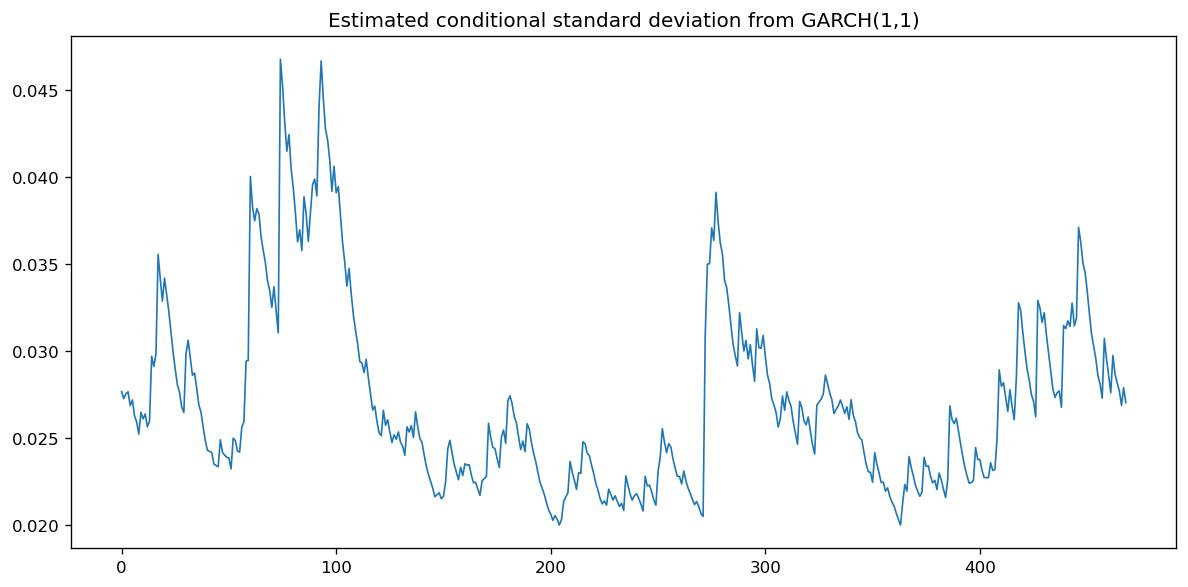

In [20]:

std_resid = garch11["resid"]

plt.figure(figsize=(10,5))
plt.plot(std_resid, linewidth=1)
plt.title("Standardized residuals from GARCH(1,1)")
plt.tight_layout()
plt.show()

plot_acf_pacf(std_resid, nlags=30)
plot_acf_pacf(std_resid**2, nlags=30)

print("ARCH-LM test on squared standardized residuals")
display(arch_lm_table(std_resid, nlags=4))

plt.figure(figsize=(10,5))
plt.plot(np.sqrt(garch11["h"]), linewidth=1)
plt.title("Estimated conditional standard deviation from GARCH(1,1)")
plt.tight_layout()
plt.show()



### Step 7: Volatility forecasting
Unlike the nonstationary mean example, the main object of interest here is not only the mean forecast but also the future conditional variance. For GARCH(1,1),
$$
\hat\sigma_{t+1|t}^2 = \omega + \alpha X_t^2 + \beta \hat\sigma_t^2,
$$
and for longer horizons the forecast reverts toward the unconditional variance if $\alpha+\beta<1$.


In [21]:

vf = garch_forecast_path(garch11, dex, steps=12)
vol_fc = pd.DataFrame({
    "forecast_variance": vf,
    "forecast_std": np.sqrt(vf)
}, index=np.arange(len(dex)+1, len(dex)+13))
vol_fc


,forecast_variance,forecast_std
470,0.000690,0.026274
471,0.000693,0.026331
472,0.000696,0.026386
473,0.000699,0.026438
474,0.000702,0.026488
475,0.000704,0.026536
476,0.000707,0.026582
477,0.000709,0.026626
478,0.000711,0.026668
479,0.000713,0.026708


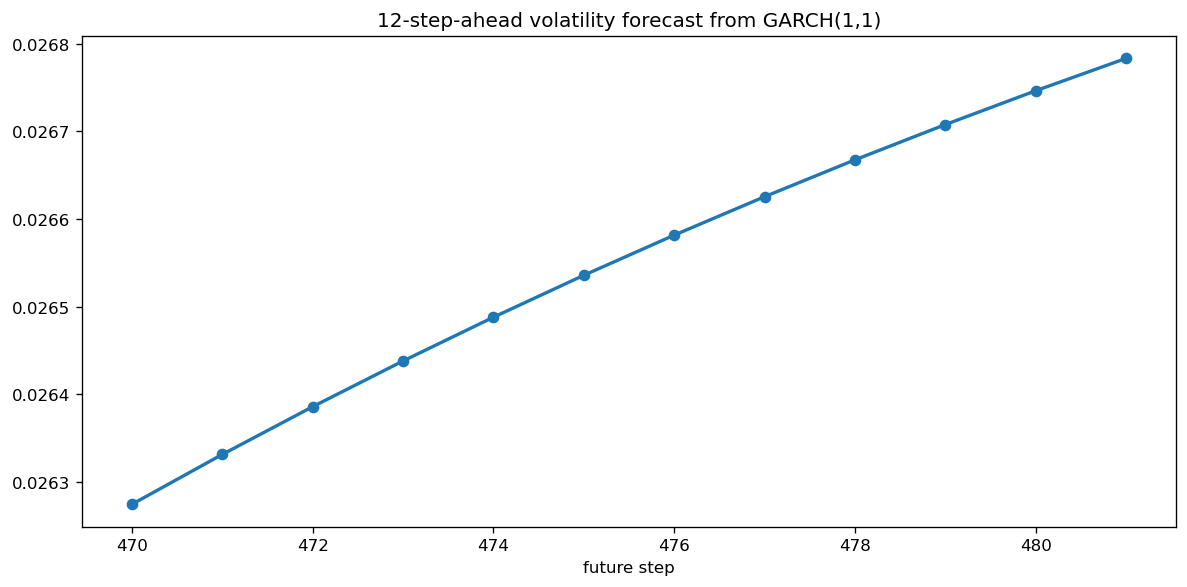

In [22]:

plt.figure(figsize=(10,5))
plt.plot(vol_fc.index, vol_fc["forecast_std"].values, marker="o", linewidth=2)
plt.title("12-step-ahead volatility forecast from GARCH(1,1)")
plt.xlabel("future step")
plt.tight_layout()
plt.show()



## Final takeaway

### Non-stationary mean workflow
- Start from the raw level series.
- Use transformations and differencing to obtain a series with stable mean behavior.
- Use ADF and KPSS as complementary tests.
- Fit ARIMA / ARMA to the transformed series and check residuals.

### Heteroskedasticity workflow
- Look at squared data, absolute data, and volatility clustering.
- Use the ARCH-LM test to confirm conditional heteroskedasticity.
- Fit ARCH/GARCH models and diagnose the standardized residuals.
- Forecast both the mean (if relevant) and the conditional variance.

Together, these two examples show how Box–Jenkins ideas extend naturally from the conditional mean to the conditional variance.
